In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform

# **Function 1** - Radiation Detection (2D)

- **Goal:** Maximise
- **All-time best:** 2.80e-06 at [0.472, 0.352] (Week 5)
- **W8 result:** -4.59e-18 at [0.378, 0.274]

Appending Week 8 result.

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

# New data for Week 8 (Function 1)
X_w8_new_point = np.array([0.378447, 0.273576], dtype=np.float64)
Y_w8_new_point = np.array([-4.5853416755437184e-18], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.378447   0.273576  ]
 [0.41043714 0.1475543 ]
 [0.472361   0.351758  ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.732441   0.040134  ]
 [0.799197   0.803213  ]
 [0.819277   0.694779  ]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  2.80463460e-006  1.03307824e-046  1.46776061e-046
 -3.60606264e-003  2.53500115e-040  7.71087511e-016 -5.11184814e-169
  4.75768881e-042 -1.84087865e-029  3.34177101e-124  6.22985647e-048
 -3.04056455e-090  0.00000000e+000]


## **Output Analysis**

- w8 returned -4.59e-18, effectively machine-zero. After 8 weeks, only one meaningful signal exists at w5 [0.472, 0.352] with output 2.80e-06.

- **Real-World Implication**: Every other query has returned machine-zero or negative values. The GP has almost nothing to build a gradient from.

- **Model Clues**: In real radiation detection, when a sensor picks up a faint signal at one location, the standard protocol is a structured outward sweep—not a probabilistic model because there isn't enough data to justify one.
    - The GP needs at least 2–3 non-zero points at different distances to estimate a gradient.

- **Key change for w9**: I am abandoning the model-led search for one week to perform a Manual Spiral Sweep and going for exploration. 
    - I will sample specifically in the North, South, East, and West directions at set distances from our only successful hit.

## **Bayesian Optimisation**
- **Model**: Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel.

- **Changes for W9**: sticking to the same model and use OUTPUT transformation.

- **Intended impact**: This should help the model continue learning and get a score which moves us away from the area we keep getting negative results.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
# Clips extreme negatives before transforming to avoid numerical issues
Y_clipped = np.clip(Y_updated, -1e10, None)
Y_transformed = power_transform(
    Y_clipped.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

# Single Matern 2.5 kernel — simpler and more stable than multi-kernel for 2 anchor points
kernel = Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)

Original Y:    [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  2.80463460e-006  1.03307824e-046  1.46776061e-046
 -3.60606264e-003  2.53500115e-040  7.71087511e-016 -5.11184814e-169
  4.75768881e-042 -1.84087865e-029  3.34177101e-124  6.22985647e-048
 -3.04056455e-090  0.00000000e+000]
Transformed Y: [ 0.23901581  0.23901581  0.23901581  0.23901581  0.23901581  0.29847154
  0.23901581  0.23901581 -4.12272456  0.23901581  0.23901581  0.23901581
  0.23901581  0.23901581  0.23901581  0.23901581  0.23901581  0.23901581]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**: Systematic Spiral Search

- **Strategy**: Deterministic Spiral Search (Cardinal Sampling).

- **Reasoning**: Since the acquisition functions (UCB/EI) have failed to find the signal for three weeks, I am using a search party logic. 
   - I go to the last known location of the signal (w5) and step out in a structured grid.

- **Key Changes**: I am manually defining the next_query coordinates. 
    - I am choosing a point at a radius of 0.02 units directly South of the Week 5 best.

In [4]:
w5_best_coord = np.array([0.472, 0.352])

# Define cardinal offsets (N, S, E, W) at various radii
radius = 0.02
next_query = np.array([w5_best_coord[0], w5_best_coord[1] - radius])

next_query = np.clip(next_query, 0, 1)

print(f'Strategic Week 8 Query (Function 1): {next_query[0]:.6f}-{next_query[1]:.6f}')

Strategic Week 8 Query (Function 1): 0.472000-0.332000


## **Visualisation**

/var/folders/gb/k_dw_jpn7yl2j5x099l7d8840000gp/T/ipykernel_82553/2905637456.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=1, alpha=0.8)


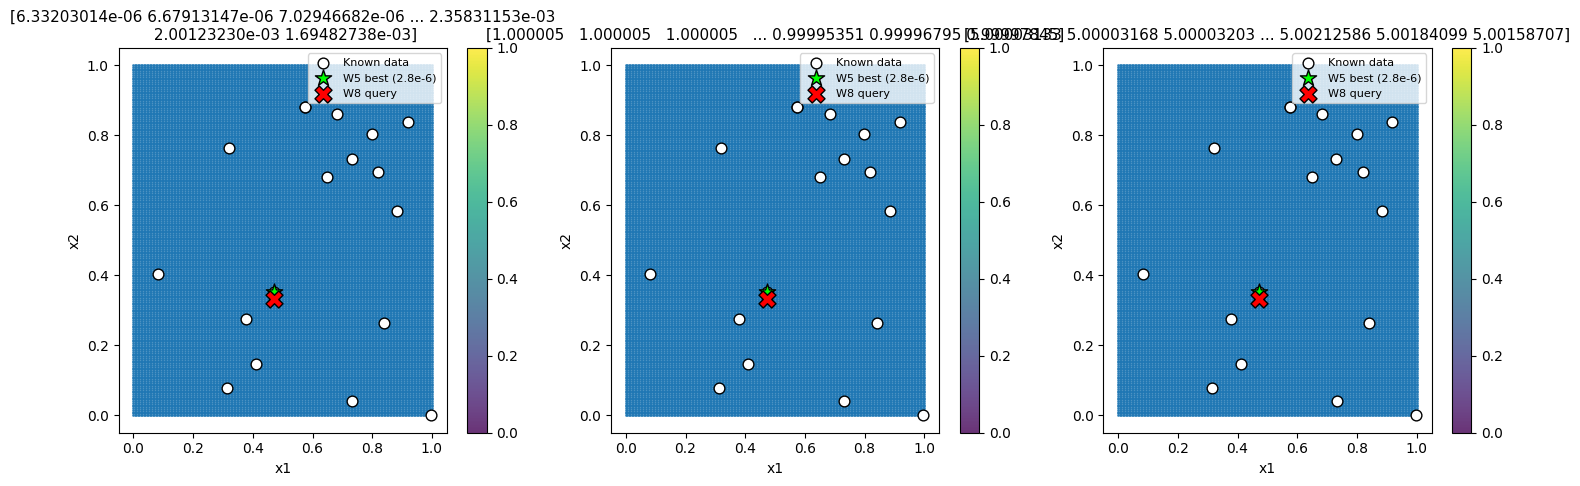

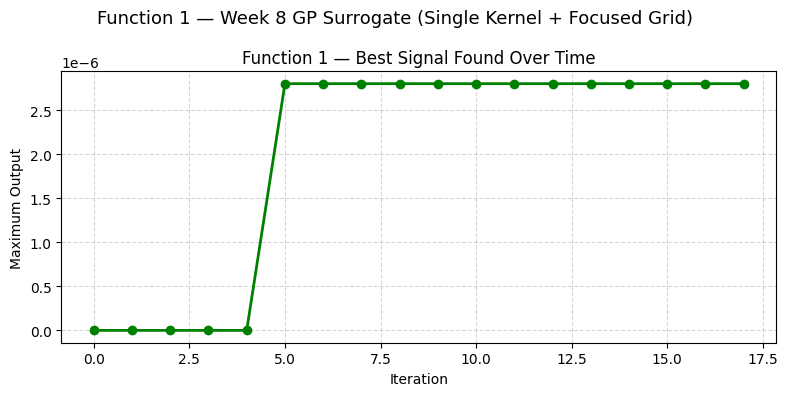

In [6]:
# Build a grid for plotting
x_plot = np.array(np.meshgrid(
    np.linspace(0, 1, 200),
    np.linspace(0, 1, 200)
)).T.reshape(-1, 2)

mu_grid, sigma_grid = model.predict(x_plot, return_std=True)
ucb_plot = mu_grid + 5.0 * sigma_grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles   = ['GP Mean (Transformed)', 'GP Uncertainty (Sigma)', 'UCB Acquisition Surface']
surfaces = [mu_grid, sigma_grid, ucb_plot]
cmaps    = ['viridis', 'plasma', 'inferno']

for ax, surface, title, cmap in zip(axes, titles, surfaces, cmaps):
    sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=1, alpha=0.8)
    ax.scatter(X_unique[:, 0], X_unique[:, 1],
               c='white', edgecolors='black', s=60, zorder=5, label='Known data')
    ax.scatter(w5_best_coord[0], w5_best_coord[1],
               c='lime', edgecolors='black', s=150, zorder=6, marker='*', label='W5 best (2.8e-6)')
    ax.scatter(next_query[0], next_query[1],
               c='red', edgecolors='black', s=150, zorder=7, marker='X', label='W8 query')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

# Progress plot
running_max = np.maximum.accumulate(Y_updated)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 1 — Best Signal Found Over Time')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 1 — Week 8 GP Surrogate (Single Kernel + Focused Grid)', fontsize=13)
plt.tight_layout()
plt.show()